# Optisches Pumpen

m = 0.588359444959464 +/- 0.0003968745642535669 1/Ohm
Widerstand = 1.699641279777359 +/- 0.0011464834941937374 Ohm


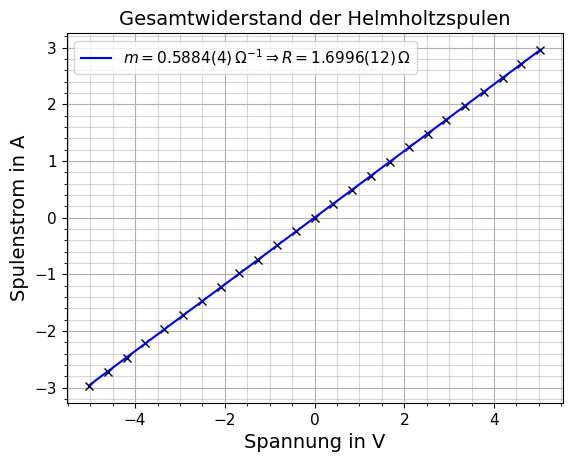

In [281]:
# Widerstand bestimmen
# Achtung, es muss auf dem Poster noch die Formel dazu, die rechtfertigt, dass der Gesamtwiderstand gleich dem Widerstand einer der Spulen ist
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

spannung, strom = np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/2_Spannung_Strom.dat', skiprows=1, unpack=True, delimiter='\t')
#strom /= 2 hier wurde der Strom aufgeteilt, um auf den Widerstand einer Spule zu kommen

fitwiderstandinv = linregress(spannung, strom)
R, R_err = 1/fitwiderstandinv.slope, 1/fitwiderstandinv.slope**2 *fitwiderstandinv.stderr

print(f"m = {fitwiderstandinv.slope} +/- {fitwiderstandinv.stderr} 1/Ohm")
print(f"Widerstand = {R} +/- {R_err} Ohm")

fig, ax = plt.subplots()

ax.plot(spannung, strom, "xk")
ax.plot(spannung, fitwiderstandinv.intercept+fitwiderstandinv.slope*spannung, "-b", label=r"$m=0.5884(4)\, \Omega^{-1} \Rightarrow R=1.6996(12)\,\Omega$")

ax.set_xlabel("Spannung in V", fontsize=14)
ax.set_ylabel("Spulenstrom in A", fontsize=14)
ax.tick_params(labelsize=11)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)

ax.set_title("Gesamtwiderstand der Helmholtzspulen", fontsize=14)
fig.savefig("../Bilder/Optisches Pumpen/Widerstand.pdf")

tau = 2.7067984102889313 +/- 0.015985430913119828 ms
Induktivität = 4.6005863141628005 +/- 0.030272797954473647 mH


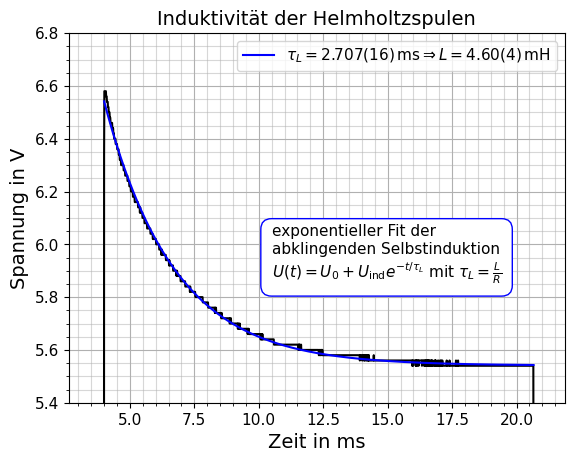

In [282]:
#Induktivität der Spulen bestimmen
from scipy.optimize import curve_fit

def f(t, U0, Uind, tau):
    return U0 + Uind*np.exp(-t/tau)

# fit für Abklingen des zusätzlichen Peaks am Rechtecksignal mit Annahme von Selbstinduktion
zeit, spannung= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/3_Induktivität_Abklingzeit_Übersicht_Stromverst_30Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')

mask = np.where(spannung>2.48)

p0 = (5, 4, 0.003)

popt, pcov = curve_fit(f, zeit[mask], spannung[mask], p0)
stderr = np.sqrt(np.diag(pcov))
tau, tau_err = popt[2], stderr[2]
L, L_err = tau*R, tau*R_err + R*tau_err

print(f"tau = {tau*10**3} +/- {tau_err*10**3} ms")
print(f"Induktivität = {L*10**3} +/- {L_err*10**3} mH")

fig, ax = plt.subplots()

ax.plot(zeit[350:2100]*1e3, spannung[350:2100], "-k")
ax.plot(zeit[mask]*1e3, f(zeit[mask],popt[0],popt[1],popt[2]), "-b", label=r"$\tau_L=2.707(16)\,\text{ms} \Rightarrow L=4.60(4)\,\text{mH}$")

ax.set_xlabel("Zeit in ms", fontsize=14)
ax.set_ylabel("Spannung in V", fontsize=14)
ax.tick_params(labelsize=11)
ax.set_ylim(5.4,6.8)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)
ax.set_title("Induktivität der Helmholtzspulen", fontsize=14)
#Textfeld mit gleichem Aussehen wie Legende in die Grafik einfügen
ax.text(0.409, 0.34, "exponentieller Fit der\nabklingenden Selbstinduktion\n" + r"$U(t) = U_0 + U_{\text{ind}} e^{-t/\tau_L}$ mit $\tau_L= \frac{L}{R}$", transform=ax.transAxes, fontsize=11, bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.7'))

fig.savefig("../Bilder/Optisches Pumpen/Induktivität.pdf")

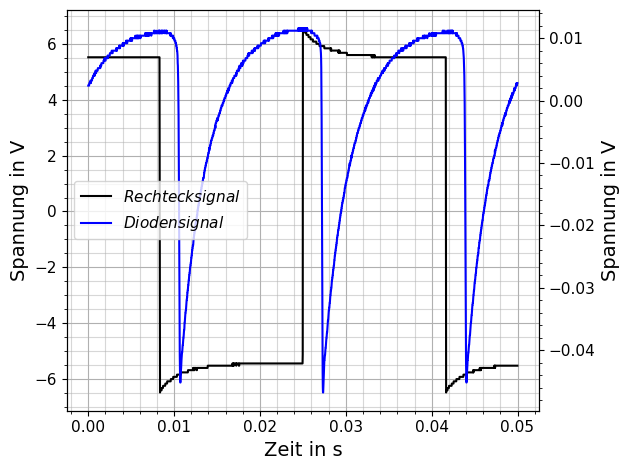

In [283]:
#Überblick

zeit, rechteck, diode= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/3_Übersicht_Stromverst_Diode_30Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

r, = ax1.plot(zeit, rechteck, "-k", label=r"$Rechtecksignal$")
d, = ax2.plot(zeit, diode, "-b", label=r"$Diodensignal$")

ax1.set_xlabel("Zeit in s", fontsize=14)
ax1.set_ylabel("Spannung in V", fontsize=14)
ax1.tick_params(labelsize=11)
ax2.set_ylabel("Spannung in V", fontsize=14)
ax2.tick_params(labelsize=11)

ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax2.legend([r,d], [r"$Rechtecksignal$", r"$Diodensignal$"], fontsize=11, loc="center left")
ax2.minorticks_on()
#ax2.grid(which='major')
#ax2.grid(which='minor', alpha=0.5)
#ax2.legend(fontsize=11)
ax.set_title("Optisches Pumpen", fontsize=14)
plt.tight_layout()
#plt.savefig("../Bilder/Optisches Pumpen/Rechtecksingal_Diodensignal.pdf")

t_0 = 1.8762096864359146 +/- 0.013611429812989675 ms


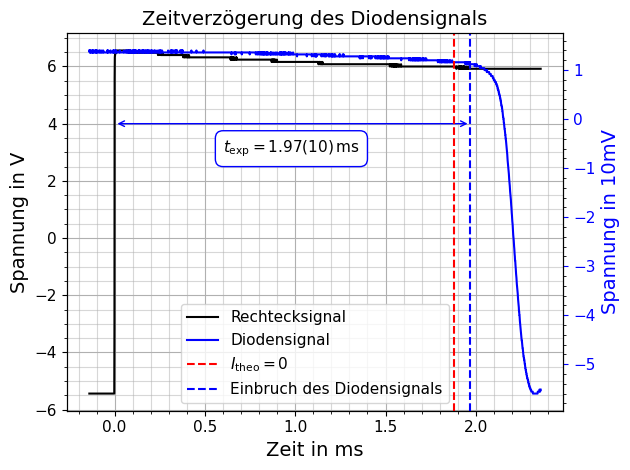

In [309]:
#Test, ob die Induktivität der Spule für die Zeitverzögerung im Diodensignal verantwortlich ist

zeit, rechteck, diode= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/3_großer_Zeitversatz_Stromverst_Diode_30Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')

#Zeitachse so verschieben, dass der Anstieg des Rechtecksignals bei t=0 liegt
zeit = zeit - zeit[np.where(rechteck>2.48)[0][0]]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(zeit*1e3, rechteck, "-k", label=r"Rechtecksignal")
ax2.plot(zeit*1e3, diode*1e2, "-b", label=r"Diodensignal")

ax1.set_xlabel("Zeit in ms", fontsize=14)
ax1.set_ylabel("Spannung in V", fontsize=14)
ax1.tick_params(labelsize=11)
ax2.set_ylabel("Spannung in 10mV", fontsize=14)
ax2.tick_params(labelsize=11)

ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax2.minorticks_on()

#Nullstelle des Stroms aus der Theorie von unten 
t_0 = L/R*np.log(2)
t_0_err = L_err/R*np.log(2) + L/R**2*R_err*np.log(2)
print(f"t_0 = {t_0*1e3} +/- {t_0_err*1e3} ms")
t_null = np.where(zeit >np.log(2)*L/R)[0][0]
ax2.axvline(x=zeit[t_null]*1e3, color='r', linestyle='--', label=r"$I_{\text{theo}}=0$")
#vertikale blaue Linie bei t=2ms
ax2.axvline(x=1.97, color='b', linestyle='--', label=r"Einbruch des Diodensignals")
#hellblauer Streifen von 1.8ms bis 2.1ms
#ax2.axvspan(1.855, 2.055, color='b', alpha=0.3)

#waagerechter Pfeil von 0 bis t_null mit Zeitdifferenz dazwischen
ax1.annotate("", xy=(1.97, 4), xytext=(0, 4), arrowprops=dict(arrowstyle="<->", color='blue'))
ax1.text(0.6,3,r"$t_{\text{exp}} = 1.97(10)\, \text{ms}$", fontsize=11, bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.5'))

#beide Legenden in einer Legende zusammenfassen
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, fontsize=11, loc="lower center")
ax1.set_title("Zeitverzögerung des Diodensignals", fontsize=14)
#ax1.text(0.15, 0.49, "Nullstelle des modellierten Stromes\n\t"+r"bei $t = \frac{L}{R}\ln(2) = 1.876(14)\,\text{ms}$"+"\npasst zu Einbruch des Diodensignals,\nalso wird die Zeitverzögerung durch\nInduktivität verursacht", transform=ax1.transAxes, fontsize=11, bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.7'))

#rechte Achse blau
#ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')


plt.tight_layout()
plt.savefig("../Bilder/Optisches Pumpen/Zeitverzögerung_Diodensignal.pdf")

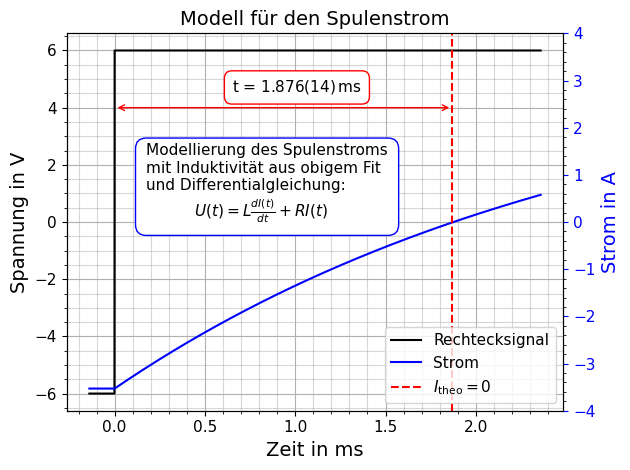

In [307]:
#Plot der Lösung der DGL für die Spulenströme

def I(t, t0, U, R, L):
    return np.where(t<t0, -U/R, U/R*(1-2*np.exp(-t*R/L)))
    
def U(t, t0, U0):
    return np.where(t<t0, -U0, U0)
    
U0 = 6
t0 = 0

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(zeit*1e3, U(zeit, t0, U0), "-k", label=r"Rechtecksignal")
ax2.plot(zeit*1e3, I(zeit, t0, U0, R, L), "-b", label=r"Strom")

ax1.set_xlabel("Zeit in ms", fontsize=14)
ax1.set_ylabel("Spannung in V", fontsize=14)
ax1.tick_params(labelsize=11)
ax2.set_ylabel("Strom in A", fontsize=14)
ax2.tick_params(labelsize=11)
ax2.set_ylim(-4,4)

ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax2.minorticks_on()

# vertikale Linie bei I=0 einzeichnen, die eigentliche Formel ln(2)*L/R gibt nur leider keinen Punkt aus zeit
t_null = np.where(I(zeit, t0, U0, R, L)>-0.01)[0][0]
ax2.axvline(x=zeit[t_null]*1e3, color='r', linestyle='--', label=r"$I_{\text{theo}}=0$")

#beide Legenden in einer Legende zusammenfassen
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, fontsize=11, loc="lower right")
ax1.set_title("Modell für den Spulenstrom", fontsize=14)
#rechte Achse blau
#ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

#waagerechter Pfeil von 0 bis t_null mit Zeitdifferenz dazwischen
ax1.annotate("", xy=(zeit[t_null]*1e3, 4), xytext=(0, 4), arrowprops=dict(arrowstyle="<->", color='r'))
ax1.text(0.65,4.55,r"t = $1.876(14)\, \text{ms}$", fontsize=11, bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.5'))

ax1.text(0.16, 0.515, "Modellierung des Spulenstroms\nmit Induktivität aus obigem Fit\nund Differentialgleichung:\n" + r"          $U(t) = L\frac{dI(t)}{dt} + RI(t)$", transform=ax1.transAxes, fontsize=11, bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.7'))

plt.tight_layout()
fig.savefig("../Bilder/Optisches Pumpen/Spulenstrom_DGL.pdf")

tau_30 = 3.351884571201713 +/- 0.005253022994580261 ms
tau_60 = 2.95729887370027 +/- 0.0060534374925529525 ms
tau_120 = 2.411537624064038 +/- 0.005543658807349471 ms


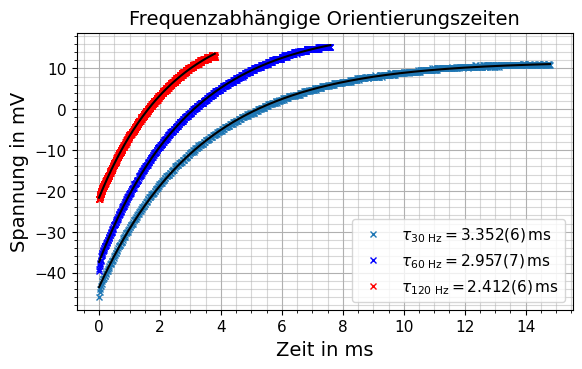

In [286]:
#Bestimmung der Orientierungszeit

def g(t, U0, Uind, tau):
    return -(U0 + Uind*np.exp(-t/tau))

z30, r30, d30= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/3_Übersicht_Stromverst_Diode_30Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')
z60, r60, d60= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/4_60Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')
z120, r120, d120= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/4_reingezoomt_120Hz_12Vpp.dat', skiprows=0, unpack=True, delimiter='\t')

#Bereiche in denen genau ein Abklingen des Diodensignals abgebildet ist
a30, b30 = 1369, 2110
a60, b60 = 710, 1470
a120, b120 = 300, 2200

#zuschneiden auf die Bereiche und alle Zeitachsen bei Null anfangen lassen
z30fit, d30fit = z30[a30:b30] - z30[a30], d30[a30:b30]
z60fit, d60fit = z60[a60:b60] - z60[a60], d60[a60:b60]
z120fit, d120fit = z120[a120:b120] - z120[a120], d120[a120:b120]


p0 = (5, 4, 0.003)

popt30, pcov30 = curve_fit(g, z30fit, d30fit, p0)
tau30, tau30_err = popt30[2], np.sqrt(np.diag(pcov30))[2]
popt60, pcov60 = curve_fit(g, z60fit, d60fit, p0)
tau60, tau60_err = popt60[2], np.sqrt(np.diag(pcov60))[2]
popt120, pcov120 = curve_fit(g, z120fit, d120fit, p0)
tau120, tau120_err = popt120[2], np.sqrt(np.diag(pcov120))[2]

print(f"tau_30 = {tau30*10**3} +/- {tau30_err*10**3} ms")
print(f"tau_60 = {tau60*10**3} +/- {tau60_err*10**3} ms")
print(f"tau_120 = {tau120*10**3} +/- {tau120_err*10**3} ms")


fig, ax1 = plt.subplots(figsize=(6.4,3.6))

ax1.plot(z30fit*1e3, d30fit*1e3, "x", label=r"$\tau_\text{30 Hz}=3.352(6)\,\text{ms}$", ms=5)
ax1.plot(z30fit*1e3, g(z30fit, popt30[0], popt30[1], popt30[2] )*1e3, "-k")#, label=r"$30\,$Hz Fit")
ax1.plot(z60fit*1e3, d60fit*1e3, "xb", label=r"$\tau_\text{60 Hz}=2.957(7)\,\text{ms}$", ms=5)
ax1.plot(z60fit*1e3, g(z60fit, popt60[0], popt60[1], popt60[2] )*1e3, "-k")#, label=r"$60\,$Hz Fit")
ax1.plot(z120fit*1e3, d120fit*1e3, "xr", label=r"$\tau_\text{120 Hz}=2.412(6)\,\text{ms}$", ms=5)
ax1.plot(z120fit*1e3, g(z120fit, popt120[0], popt120[1], popt120[2] )*1e3, "-k")#, label=r"$120\,$Hz Fit")

ax1.set_xlabel("Zeit in ms", fontsize=14)
ax1.set_ylabel("Spannung in mV", fontsize=14)
ax1.tick_params(labelsize=11)

ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax1.legend(fontsize=11)
ax1.set_title("Frequenzabhängige Orientierungszeiten", fontsize=14)
fig.savefig("../Bilder/Optisches Pumpen/Orientierungszeiten_Freq.pdf")

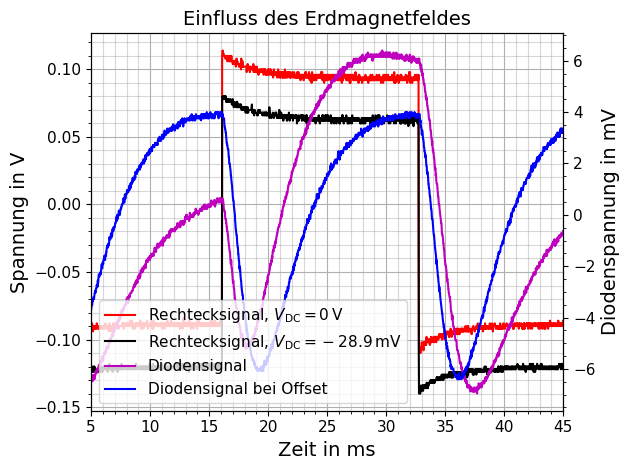

In [310]:
#Visualisierung der Erdmagnetfeldbestimmung
import os

#plotten aller Dateien mit 5_ am Anfang und ohne _ScopeSetting im Namen
# als Übersicht, um festzustellen, welche Bilder wir haben wollen
'''for filename in os.listdir(r'../Messdaten/20260511_Optisches_Pumpen/'):
    if filename.startswith("5_") and not filename.endswith("_ScopeSettings.txt"):
        zeit, rechteck, diode= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/'+filename, skiprows=0, unpack=True, delimiter='\t')
        plt.plot(zeit, diode, label=filename[2:-4])
        #plt.plot(zeit, rechteck, label=filename[2:-4])
        plt.xlabel("Zeit in s", fontsize=14)
        plt.ylabel("Spannung in V", fontsize=14)
        plt.title(filename[2:-4])
        plt.legend()
        plt.show()'''

zeit1, rechteck1, diode1= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/5_para_30Hz_200mVpp_-34mV6off.dat', skiprows=0, unpack=True, delimiter='\t')
zeit2, rechteck2, diode2= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/5_para_30Hz_200mVpp_0off.dat', skiprows=53, unpack=True, delimiter='\t')

#zeit2 so verschieben, dass die Rechtecksignale übereinander liegen
zeit2 = zeit2 - zeit2[0]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(zeit2*1e3, rechteck2, "-r", label=r"Rechtecksignal, $V_\text{DC}=0\,\text{V}$")
ax2.plot(zeit2*1e3, diode2*1e3, "-m", label=r"Diodensignal")
ax1.plot(zeit1*1e3, rechteck1, "-k", label=r"Rechtecksignal, $V_\text{DC}=-28.9\,\text{mV}$")
ax2.plot(zeit1*1e3, diode1*1e3, "-b", label=r"Diodensignal bei Offset")

ax1.set_xlabel("Zeit in ms", fontsize=14)
ax1.set_ylabel("Spannung in V", fontsize=14)
ax1.tick_params(labelsize=11)
ax2.set_ylabel("Diodenspannung in mV", fontsize=14)
ax2.tick_params(labelsize=11)

ax1.minorticks_on()
ax1.grid(which='major')
ax1.grid(which='minor', alpha=0.5)
ax2.minorticks_on()

#beide Legenden in einer Legende zusammenfassen
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, fontsize=11)
ax1.set_title("Einfluss des Erdmagnetfeldes", fontsize=14)
ax2.set_xlim(5,45)
plt.tight_layout()
fig.savefig("../Bilder/Optisches Pumpen/Erdmagnetfeld.pdf")

m = 11.034689043689884 +/- 0.0023235117701088104 V/s
b = -5.487624009356823 +/- 0.0013175138667663492 V


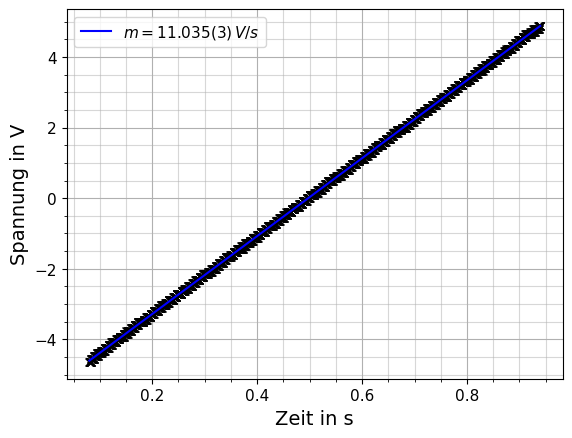

In [288]:
#RF-Messung bei moduliertem Magnetfeld -> g-Faktor

#Formel für das Magnetfeld, um die Spannungsrampe der RF-Messung in Magnetfeldstärke umzurechnen
def B(U):
    mu_0=4*np.pi*10**(-7)
    r = 0.09
    N = 80*2 # hatte sich vorher mit dem Faktor beim Widerstand rausgekürzt, jetzt haben wir aber den Faktor in den Widerstand reingezogen
    U0 = 0.0346
    return mu_0*(4/5)**(3/2)*N/r*(U-U0)/R

# leider ist die gemessene Spannung ziemlich unschön, also vorher Fit um ne schicke Umrechnung von Zeit zu Magnetfeld zu haben
zeit, rampe, diode= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/6_RF_0Mhz5.dat', skiprows=200, max_rows=2150, unpack=True, delimiter='\t')

fitSpannungZeit = linregress(zeit, rampe)
m, m_err = fitSpannungZeit.slope, fitSpannungZeit.stderr
b, b_err = fitSpannungZeit.intercept, fitSpannungZeit.intercept_stderr

print(f"m = {fitSpannungZeit.slope} +/- {fitSpannungZeit.stderr} V/s")
print(f"b = {fitSpannungZeit.intercept} +/- {fitSpannungZeit.intercept_stderr} V")

fig, ax = plt.subplots()

ax.plot(zeit, rampe, "xk")
ax.plot(zeit, fitSpannungZeit.intercept+fitSpannungZeit.slope*zeit, "-b", label=r"$m=11.035(3)\, V/s$")

ax.set_xlabel("Zeit in s", fontsize=14)
ax.set_ylabel("Spannung in V", fontsize=14)
ax.tick_params(labelsize=11)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)


Peak-Indizes: [1004, 1025, 1082, 1104]
Peak-Werte: [-0.017801 -0.0076   -0.0012   -0.008001]
Peak-Positionen: [-0.19554947 -0.10837197  0.12825269  0.2195815 ]
Peak-Indizes: [948, 985, 1124, 1162]
Peak-Werte: [-0.018601 -0.0046    0.       -0.013401]
Peak-Positionen: [-0.42802282 -0.27442436  0.3026077   0.46035747]
Peak-Indizes: [ 892  947 1161 1215]
Peak-Werte: [-0.020201 -0.0054   -0.003    -0.018001]
Peak-Positionen: [-0.66049616 -0.43217413  0.45620616  0.68037688]
Peak-Indizes: [ 837  910 1197 1271]
Peak-Werte: [-0.018001 -0.005    -0.0038   -0.016601]
Peak-Positionen: [-0.8888182  -0.58577259  0.60565331  0.91285023]
Peak-Indizes: [ 785  876 1238 1329]
Peak-Werte: [-0.014601 -0.0046   -0.0042   -0.013601]
Peak-Positionen: [-1.1046863  -0.72691712  0.77585701  1.15362619]
Peak-Indizes: [ 728  837 1271 1382]
Peak-Werte: [-0.014201 -0.0058   -0.0056   -0.013601]
Peak-Positionen: [-1.34131096 -0.8888182   0.91285023  1.37364561]
Peak-Indizes: [ 673  799 1308 1436]
Peak-Werte: [-0.01

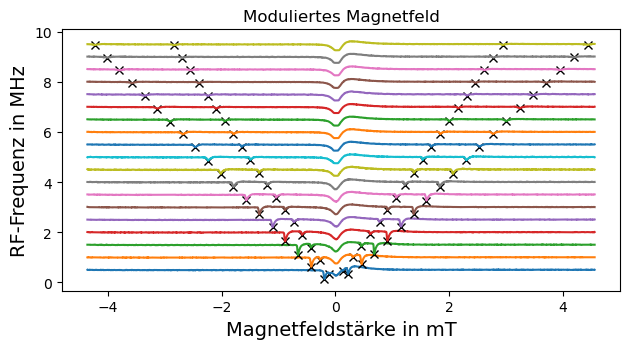

In [289]:
# Fortsetzung: Plotten und Peaks finden
from scipy.signal import find_peaks

#plotten aller Dateien mit 6_ am Anfang und ohne _ScopeSetting im Namen
# die Plots müssen durch ein y-Offset so verschoben werden, dass die diodensignale nicht überlappen
offset = 0.5
#festlegen einer maximalen Peakbreite um die Peaks vom Umpolen zu eliminieren
max_width = 35
# array in dem die gefundenen Peaks gespeichert werden, um sie später für die g-Faktor Berechnung zu verwenden
peak85_B = []
peak85_f = []
peak87_B = []
peak87_f = []

fig, ax = plt.subplots(figsize=(6.4,3.6))
    
for filename in os.listdir(r'../Messdaten/20260511_Optisches_Pumpen/'): 
    if filename.startswith("6_") and not filename.endswith("_ScopeSettings.txt") and not filename.startswith("6_RF_10") and not filename.startswith("6_Peaks"):
        zeit, rampe, diode= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/'+filename, skiprows=200, max_rows=2150, unpack=True, delimiter='\t')
        
        peaks, properties = find_peaks(-1*diode, height=0.0008, distance=20, prominence=0.002, width=(0, max_width))
        
        if filename.startswith("6_RF_0Mhz5"):
            peaks = [1004, 1025, 1082, 1104] # Achtung hardgecoded für skiprows=200
        elif filename.startswith("6_RF_1Mhz0"):
            peaks = [ 948,  985, 1124, 1162]
        elif filename.startswith("6_RF_9Mhz5"):
            peaks = [  32,  365, 1759, 2121]

        peak85_B.extend([(B(m*zeit+b)[peaks][3]- B(m*zeit+b)[peaks][0])/2])
        peak87_B.extend([(B(m*zeit+b)[peaks][2]- B(m*zeit+b)[peaks][1])/2])    
        peak85_f.extend([10**6*offset])
        peak87_f.extend([10**6*offset])

        plt.plot(1000*B(m*zeit+b)[peaks], diode[peaks]*20+offset, "xk")
        plt.plot(1000*B(m*zeit+b), diode*20+offset)
        print("Peak-Indizes:", peaks)
        print("Peak-Werte:", diode[peaks])
        print("Peak-Positionen:", 1000*B(m*zeit+b)[peaks])
        offset += 0.5



#Schreiben der gefundenen Peaks in eine Datei, falls irgendwann mal der Code kapeister geht
#with open("../Messdaten/20260511_Optisches_Pumpen/6_Peaks.dat", "w") as f:
#    f.write("B85 in mT\tf85 in MHz\tB87 in mT\tf87 in MHz\n")
#    for b85, f85, b87, f87 in zip(peak85_B, peak85_f, peak87_B, peak87_f):
#        f.write(f"{b85}\t{f85}\t{b87}\t{f87}\n")

plt.title("Moduliertes Magnetfeld")
plt.xlabel("Magnetfeldstärke in mT", fontsize=14)
plt.ylabel("RF-Frequenz in MHz", fontsize=14)
plt.tight_layout()
plt.savefig("../Bilder/Optisches Pumpen/Magnetfeld_Rampe.pdf")
plt.show()

m85_6 = 4.5761270983528684e-10 +/- 2.6922772041849514e-13 V/s
b85_6 = -1.7078633911539812e-05 +/- 1.5348341528831478e-06 V
g85_6 = 0.1561314495246737 +/- 9.185696406092672e-05
m87_6 = 3.0667254445505155e-10 +/- 3.698292703884169e-13 V/s
b87_6 = -2.021032371194928e-05 +/- 2.108351227896086e-06 V
g87_6 = 0.23297728146632052 +/- 0.00028095706505084527


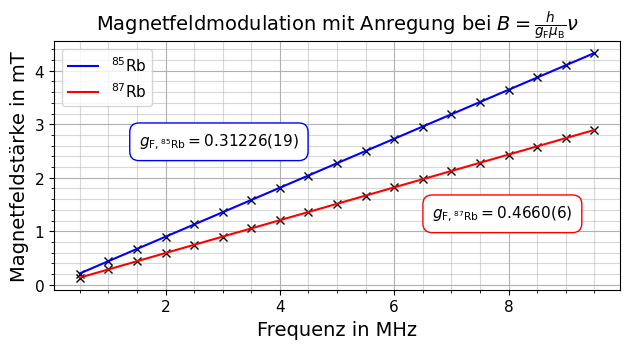

In [290]:
# g Faktor bestimmen

mu_B = 9.274009994*10**(-24)
h = 6.62607015*10**(-34)

fit85_B_f = linregress(peak85_f, peak85_B)
m85_6, m85_6_err = fit85_B_f.slope, fit85_B_f.stderr
b85_6, b85_6_err = fit85_B_f.intercept, fit85_B_f.intercept_stderr
g85_6, g85_6_err = h/mu_B*1/m85_6, h/mu_B*1/m85_6**2 * m85_6_err

# jetzt nochmal fpr 87
fit87_B_f = linregress(peak87_f, peak87_B)
m87_6, m87_6_err = fit87_B_f.slope, fit87_B_f.stderr
b87_6, b87_6_err = fit87_B_f.intercept, fit87_B_f.intercept_stderr
g87_6, g87_6_err = h/mu_B*1/m87_6, h/mu_B*1/m87_6**2 * m87_6_err

print(f"m85_6 = {fit85_B_f.slope} +/- {fit85_B_f.stderr} V/s")
print(f"b85_6 = {fit85_B_f.intercept} +/- {fit85_B_f.intercept_stderr} V")
print(f"g85_6 = {g85_6} +/- {g85_6_err}")
print(f"m87_6 = {fit87_B_f.slope} +/- {fit87_B_f.stderr} V/s")
print(f"b87_6 = {fit87_B_f.intercept} +/- {fit87_B_f.intercept_stderr} V")
print(f"g87_6 = {g87_6} +/- {g87_6_err}")

fig, ax = plt.subplots(figsize=(6.4,3.6))

ax.plot(np.array(peak85_f)/1e6, 1000*np.array(peak85_B), "xk")
ax.plot(np.array(peak85_f)/1e6, 1000*(fit85_B_f.intercept+fit85_B_f.slope*np.array(peak85_f)), "-b", label=r"$^{85}$"+"Rb")
ax.plot(np.array(peak87_f)/1e6, 1000*np.array(peak87_B), "xk")
ax.plot(np.array(peak87_f)/1e6, 1000*(fit87_B_f.intercept+fit87_B_f.slope*np.array(peak87_f)), "-r", label=r"$^{87}$"+"Rb")

ax.set_xlabel("Frequenz in MHz", fontsize=14)
ax.set_ylabel("Magnetfeldstärke in mT", fontsize=14)
ax.tick_params(labelsize=11)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)
#blauer und roter Text mit den g-Faktoren in die Grafik einfügen
ax.text(0.15, 0.58, r"$g_{\text{F}, ^{85}\text{Rb}}=0.31226(19)$", transform=ax.transAxes, fontsize=11, color='black', bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.6'))
ax.text(0.668, 0.29, r"$g_{\text{F}, ^{87}\text{Rb}}=0.4660(6)$", transform=ax.transAxes, fontsize=11, color='black', bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.6'))

ax.set_title(r"Magnetfeldmodulation mit Anregung bei $B=\frac{h}{g_\text{F}\mu_\text{B}}\nu$", fontsize=14)

fig.tight_layout()
fig.savefig("../Bilder/Optisches Pumpen/Lande_B(f).pdf")

Stromstärke: -0.0 A -> Magnetfeld: -0.0 mT 
Stromstärke: -0.24 A -> Magnetfeld: -0.19182427425561882 mT 
Stromstärke: -0.47 A -> Magnetfeld: -0.3756558704172535 mT 
Stromstärke: -0.71 A -> Magnetfeld: -0.5674801446728723 mT 
Stromstärke: -0.94 A -> Magnetfeld: -0.751311740834507 mT 
Stromstärke: -1.17 A -> Magnetfeld: -0.9351433369961417 mT 
Stromstärke: -1.41 A -> Magnetfeld: -1.1269676112517606 mT 
Stromstärke: -1.64 A -> Magnetfeld: -1.3107992074133954 mT 
Stromstärke: -1.87 A -> Magnetfeld: -1.4946308035750302 mT 
Stromstärke: -2.1 A -> Magnetfeld: -1.678462399736665 mT 
Stromstärke: -2.33 A -> Magnetfeld: -1.8622939958982996 mT 
Stromstärke: 0.24 A -> Magnetfeld: 0.19182427425561882 mT 
Stromstärke: 0.48 A -> Magnetfeld: 0.38364854851123764 mT 
Stromstärke: 0.72 A -> Magnetfeld: 0.5754728227668564 mT 
Stromstärke: 0.96 A -> Magnetfeld: 0.7672970970224753 mT 
Stromstärke: 1.2 A -> Magnetfeld: 0.959121371278094 mT 
Stromstärke: 1.44 A -> Magnetfeld: 1.1509456455337128 mT 
Stromstärk

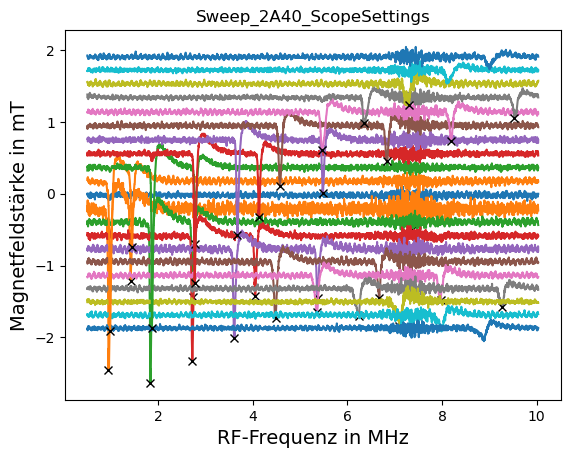

In [291]:
#RF-Sweep bei festem Magnetfeld -> g-Faktor
#Funktion um die Zeitachse in eine Frequanzachse umzurechnen
def f(zeit):
    return (9.5*10**9/996)*zeit+0.5*10**6
def B(I):
    mu_0=4*np.pi*10**(-7)
    r = 0.09
    N = 80#*2 # hatte sich vorher mit dem Faktor beim Widerstand rausgekürzt, jetzt haben wir aber den Faktor in den Widerstand reingezogen
                # aber der Strom teil sich ja auf, von daher doch weg
    return mu_0*(4/5)**(3/2)*N/r*I

#Listen zum Speichern der gefundenen Peaks
peak85_B_7 = []
peak85_f_7 = []
peak87_B_7 = []
peak87_f_7 = []


#plotten aller Dateien mit 7_ am Anfang und ohne _ScopeSetting im Namen
for filename in os.listdir(r'../Messdaten/20260511_Optisches_Pumpen/'):
    if filename.startswith("7_Sweep_") and not filename.endswith("_ScopeSettings.txt"):
        zeit, spannung, diode= np.loadtxt(r'../Messdaten/20260511_Optisches_Pumpen/'+filename, skiprows=0, unpack=True, delimiter='\t')
        
        #filename auslesen für Stromstärke
        if len(filename) == 16:
            I = float(filename[8]+"."+filename[10:12])
        else:            I = float(filename[8:10]+"."+filename[11:13])
        
        B_temp = B(I)
        print(f"Stromstärke: {I} A -> Magnetfeld: {B_temp*10**3} mT ")

        peaks, properties = find_peaks(-1*diode, height=0.0025, distance=20, prominence=0.002)

        if len(peaks) >= 2:
            peak85_B_7.append(abs(B_temp))
            peak87_B_7.append(abs(B_temp))    
            peak85_f_7.append(f(zeit[peaks][0]))
            peak87_f_7.append(f(zeit[peaks][1]))
        
        
        plt.plot(f(zeit)*10**(-6), diode*100+B_temp*1000, "-")
        plt.plot(f(zeit[peaks])*10**(-6), diode[peaks]*100+B_temp*1000, "xk")   
        
plt.ylabel("Magnetfeldstärke in mT", fontsize=14)
plt.xlabel("RF-Frequenz in MHz", fontsize=14)
plt.title(filename[2:-4])
plt.show()      

m85_7 = 4686638048.288477 +/- 14968820.091145214 V/s
b85_7 = 70796.19083472481 +/- 12714.189354337024 V
g85_7 = 0.3348496766308158 +/- 0.001069488301725218
m87_7 = 7011053253.601968 +/- 13001532.277957829 V/s
b87_7 = 91980.231605771 +/- 11043.217987252447 V
g87_7 = 0.500923879894542 +/- 0.0009289300419880254


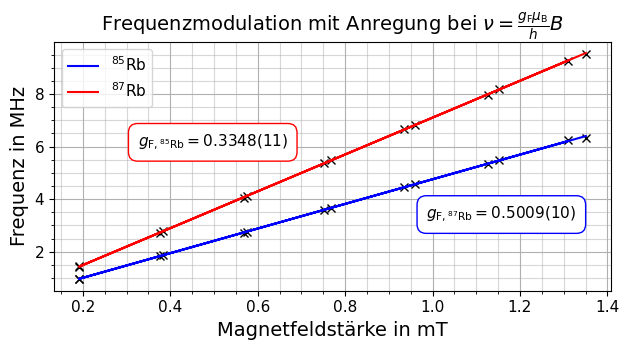

In [292]:
# Bestimmung des g-Faktors aus den Peaks

fit85_f_B = linregress(peak85_B_7, peak85_f_7)
m85_7, m85_7_err = fit85_f_B.slope, fit85_f_B.stderr
b85_7, b85_7_err = fit85_f_B.intercept, fit85_f_B.intercept_stderr
g85_7, g85_7_err = h/mu_B*m85_7, h/mu_B * m85_7_err

# jetzt nochmal fpr 87
fit87_f_B = linregress(peak87_B_7, peak87_f_7)
m87_7, m87_7_err = fit87_f_B.slope, fit87_f_B.stderr
b87_7, b87_7_err = fit87_f_B.intercept, fit87_f_B.intercept_stderr
g87_7, g87_7_err = h/mu_B*m87_7, h/mu_B* m87_7_err

print(f"m85_7 = {fit85_f_B.slope} +/- {fit85_f_B.stderr} V/s")
print(f"b85_7 = {fit85_f_B.intercept} +/- {fit85_f_B.intercept_stderr} V")
print(f"g85_7 = {g85_7} +/- {g85_7_err}")
print(f"m87_7 = {fit87_f_B.slope} +/- {fit87_f_B.stderr} V/s")
print(f"b87_7 = {fit87_f_B.intercept} +/- {fit87_f_B.intercept_stderr} V")
print(f"g87_7 = {g87_7} +/- {g87_7_err}")

fig, ax = plt.subplots(figsize=(6.4,3.6))

ax.plot(np.array(peak85_B_7)*1000, np.array(peak85_f_7)/1e6,  "xk")
ax.plot(np.array(peak85_B_7)*1000, np.array(fit85_f_B.intercept+fit85_f_B.slope*np.array(peak85_B_7))/1e6, "-b", label=r"$^{85}$"+"Rb")
ax.plot(np.array(peak87_B_7)*1000, np.array(peak87_f_7)/1e6, "xk")
ax.plot(np.array(peak87_B_7)*1000, np.array(fit87_f_B.intercept+fit87_f_B.slope*np.array(peak87_B_7))/1e6, "-r", label=r"$^{87}$"+"Rb")

ax.set_ylabel("Frequenz in MHz", fontsize=14)
ax.set_xlabel("Magnetfeldstärke in mT", fontsize=14)
ax.tick_params(labelsize=11)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.legend(fontsize=11)

#blauer und roter Text mit den g-Faktoren in die Grafik einfügen
ax.text(0.15, 0.58, r"$g_{\text{F}, ^{85}\text{Rb}}=0.3348(11)$", transform=ax.transAxes, fontsize=11, color='black', bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.6'))
ax.text(0.668, 0.29, r"$g_{\text{F}, ^{87}\text{Rb}}=0.5009(10)$", transform=ax.transAxes, fontsize=11, color='black', bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.6'))

ax.set_title(r"Frequenzmodulation mit Anregung bei $\nu=\frac{g_\text{F}\mu_\text{B}}{h}B$", fontsize=14)

fig.tight_layout()
fig.savefig("../Bilder/Optisches Pumpen/Lande_f(B).pdf")